In [192]:
"""
Matching rate computation for flexibility allocation in bipartite stochastic block models.

Functions:
    compute_eta_OS(alpha, alpha_f, B) -> one-sided matching rate
    compute_eta_TS(alpha, alpha_f, B) -> two-sided matching rate

All functions accept scalar or array inputs (broadcast-compatible).

Code to implement simulations and generate figures used in manuscript.
"""

import numpy as np
from scipy.optimize import minimize_scalar, minimize
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.sparse import csc_matrix
from scipy.sparse.csgraph import maximum_bipartite_matching
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from tqdm import tqdm


plt.rc('text', usetex=True) # to use LaTeX font in figures
plt.rc('font', family='serif')

# ---------------------------------------------------------------------------
# Objective functions
# ---------------------------------------------------------------------------

def F_OS(t1, alpha, alpha_f, B):
    """
    One-sided variational objective F_OS(t1) from Corollary 1.

    Parameters
    ----------
    t1 : float or ndarray
        Optimization variable(s) in [0, 1].
    alpha, alpha_f, B : float
        Model parameters.

    Returns
    -------
    float or ndarray
    """
    M = 2.0 * alpha + (alpha_f - alpha) * B
    u = np.exp(-M * t1)
    return ((1.0 - B) * np.exp(-2.0 * alpha * u)
            + B * np.exp(-(alpha + alpha_f) * u)
            + u * (1.0 + M * t1) - 1.0)


def F_TS(t1, t2, alpha, alpha_f, B):
    """
    Two-sided variational objective F_TS(t1, t2) from Corollary 2.

    Parameters
    ----------
    t1, t2 : float or ndarray
        Optimization variables in [0, 1].
    alpha, alpha_f, B : float
        Model parameters.

    Returns
    -------
    float or ndarray
    """
    p = 1.0 - B / 2.0
    q = B / 2.0
    M1 = (2.0 - B / 2.0) * alpha + (B / 2.0) * alpha_f
    M2 = (1.0 - B / 2.0) * alpha + (1.0 + B / 2.0) * alpha_f

    u1 = np.exp(-M1 * t1)
    u2 = np.exp(-M2 * t2)

    # Coefficients in the exponentials
    A11 = 2.0 * alpha * p            # 2 alpha (1 - B/2)
    A12 = (alpha + alpha_f) * q      # (alpha + alpha_f) B/2
    A21 = (alpha + alpha_f) * p      # (alpha + alpha_f)(1 - B/2)
    A22 = alpha_f * B                # alpha_f B

    return (p * np.exp(-A11 * u1 - A12 * u2)
            + q * np.exp(-A21 * u1 - A22 * u2)
            + p * u1 * (1.0 + M1 * t1)
            + q * u2 * (1.0 + M2 * t2) - 1.0)


# ---------------------------------------------------------------------------
# Internal: negative objective + analytical gradient for 2-D L-BFGS-B
# ---------------------------------------------------------------------------

def _neg_F_TS_with_grad(t_vec, alpha, alpha_f, B):
    """Return (-F_TS, -grad F_TS) for use with scipy.optimize.minimize."""
    t1, t2 = t_vec[0], t_vec[1]
    p = 1.0 - B / 2.0
    q = B / 2.0
    M1 = (2.0 - B / 2.0) * alpha + (B / 2.0) * alpha_f
    M2 = (1.0 - B / 2.0) * alpha + (1.0 + B / 2.0) * alpha_f

    u1 = np.exp(-M1 * t1)
    u2 = np.exp(-M2 * t2)

    A11 = 2.0 * alpha * p
    A12 = (alpha + alpha_f) * q
    A21 = (alpha + alpha_f) * p
    A22 = alpha_f * B

    E1 = np.exp(-A11 * u1 - A12 * u2)
    E2 = np.exp(-A21 * u1 - A22 * u2)

    val = (p * E1 + q * E2
           + p * u1 * (1.0 + M1 * t1)
           + q * u2 * (1.0 + M2 * t2) - 1.0)

    # Analytical gradients (derived from the chain rule)
    #   dF/dt1 = M1 u1 [ p A11 E1 + q A21 E2 - p M1 t1 ]
    #   dF/dt2 = M2 u2 [ p A12 E1 + q A22 E2 - q M2 t2 ]
    g1 = M1 * u1 * (p * A11 * E1 + q * A21 * E2 - p * M1 * t1)
    g2 = M2 * u2 * (p * A12 * E1 + q * A22 * E2 - q * M2 * t2)

    return -val, np.array([-g1, -g2])


# ---------------------------------------------------------------------------
# Internal: single-instance solvers
# ---------------------------------------------------------------------------

def _solve_max_F_OS(alpha, alpha_f, B):
    """Return max_{t1 in [0,1]} F_OS(t1) for a single parameter triple."""
    M = 2.0 * alpha + (alpha_f - alpha) * B

    # Dense adaptive grid: uniform + scale-adapted points near 0
    pts = set(np.linspace(0.0, 1.0, 51).tolist())
    if M > 0.5:
        for s in [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]:
            v = s / M
            if 0.0 < v < 1.0:
                pts.add(v)
    grid = np.array(sorted(pts))
    grid_vals = F_OS(grid, alpha, alpha_f, B)
    best_val = np.max(grid_vals)

    # Refine from each local-maximum basin
    # Identify grid points that are local maxima (including endpoints)
    n = len(grid_vals)
    for i in range(n):
        is_local_max = True
        if i > 0 and grid_vals[i] < grid_vals[i - 1]:
            is_local_max = False
        if i < n - 1 and grid_vals[i] < grid_vals[i + 1]:
            is_local_max = False
        if not is_local_max:
            continue
        lo = grid[max(i - 1, 0)]
        hi = grid[min(i + 1, n - 1)]
        res = minimize_scalar(
            lambda t: -F_OS(t, alpha, alpha_f, B),
            bounds=(lo, hi),
            method='bounded',
            options={'xatol': 1e-14, 'maxiter': 500},
        )
        val = -res.fun
        if val > best_val:
            best_val = val

    return best_val


def _solve_max_F_TS(alpha, alpha_f, B):
    """Return max_{(t1,t2) in [0,1]^2} F_TS(t1,t2) for a single triple."""
    M1 = (2.0 - B / 2.0) * alpha + (B / 2.0) * alpha_f
    M2 = (1.0 - B / 2.0) * alpha + (1.0 + B / 2.0) * alpha_f
    bounds = [(0.0, 1.0), (0.0, 1.0)]

    # --- Phase 1: dense adaptive grid (vectorised) -------------------------
    def _make_grid(M, n_uniform=21):
        pts = set(np.linspace(0.0, 1.0, n_uniform).tolist())
        if M > 0.5:
            for s in [0.1, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]:
                v = s / M
                if 0.0 < v < 1.0:
                    pts.add(v)
        return np.array(sorted(pts))

    g1 = _make_grid(M1)
    g2 = _make_grid(M2)
    T1g, T2g = np.meshgrid(g1, g2)
    t1_flat, t2_flat = T1g.ravel(), T2g.ravel()
    grid_vals = F_TS(t1_flat, t2_flat, alpha, alpha_f, B)

    # --- Phase 2: multi-start L-BFGS-B from top grid points ----------------
    best_val = np.max(grid_vals)
    n_starts = min(8, len(grid_vals))
    top_idx = np.argsort(grid_vals)[-n_starts:]

    # Deduplicate starts: keep only spatially distinct seeds
    starts = []
    for idx in reversed(top_idx):          # highest-value first
        t1c, t2c = t1_flat[idx], t2_flat[idx]
        is_dup = False
        for (s1, s2) in starts:
            if abs(t1c - s1) < 0.03 and abs(t2c - s2) < 0.03:
                is_dup = True
                break
        if not is_dup:
            starts.append((t1c, t2c))

    for (t1_init, t2_init) in starts:
        res = minimize(
            _neg_F_TS_with_grad,
            x0=np.array([t1_init, t2_init]),
            args=(alpha, alpha_f, B),
            jac=True,
            bounds=bounds,
            method='L-BFGS-B',
            options={'ftol': 1e-15, 'gtol': 1e-12, 'maxiter': 500},
        )
        val = -res.fun
        if val > best_val:
            best_val = val

    return best_val


# ---------------------------------------------------------------------------
# Public 
# ---------------------------------------------------------------------------

def compute_eta_OS(alpha, alpha_f, B):
    """
    One-sided matching rate  eta_OS(B, alpha, alpha_f).

        eta_OS = 1 - max_{t1 in [0,1]} F_OS(t1)

    Parameters
    ----------
    alpha, alpha_f, B : float or array-like  (broadcast-compatible)

    Returns
    -------
    float or ndarray
    """
    scalar = np.isscalar(alpha) and np.isscalar(alpha_f) and np.isscalar(B)
    alpha, alpha_f, B = np.broadcast_arrays(
        np.asarray(alpha, dtype=float),
        np.asarray(alpha_f, dtype=float),
        np.asarray(B, dtype=float),
    )
    shape = alpha.shape
    out = np.empty(alpha.size)
    for i in range(alpha.size):
        out[i] = 1.0 - _solve_max_F_OS(alpha.flat[i], alpha_f.flat[i], B.flat[i])
    out = out.reshape(shape)
    return float(out) if scalar else out


def compute_eta_TS(alpha, alpha_f, B):
    """
    Two-sided (balanced) matching rate  eta_TS(B, alpha, alpha_f).

        eta_TS = 1 - max_{(t1,t2) in [0,1]^2} F_TS(t1,t2)

    Parameters
    ----------
    alpha, alpha_f, B : float or array-like  (broadcast-compatible)

    Returns
    -------
    float or ndarray
    """
    scalar = np.isscalar(alpha) and np.isscalar(alpha_f) and np.isscalar(B)
    alpha, alpha_f, B = np.broadcast_arrays(
        np.asarray(alpha, dtype=float),
        np.asarray(alpha_f, dtype=float),
        np.asarray(B, dtype=float),
    )
    shape = alpha.shape
    out = np.empty(alpha.size)
    for i in range(alpha.size):
        out[i] = 1.0 - _solve_max_F_TS(alpha.flat[i], alpha_f.flat[i], B.flat[i])
    out = out.reshape(shape)
    return float(out) if scalar else out

# Figure Generation

## Empirical Verification vs. Hopcroft-Karp

In [106]:
def simulate_matching_rate(alpha, alpha_f, B, alloc, n=10_000, n_trials=10):
    """
    Simulate bipartite SBM and return (mean, std) of matching fraction.
    Uses fast Poisson-count edge sampling + Hopcroft-Karp via scipy.
    """
    bL, bR = (B, 0.0) if alloc == 'OS' else (B / 2.0, B / 2.0)
    C = np.array([[2 * alpha,       alpha + alpha_f],
                  [alpha + alpha_f, 2 * alpha_f]])

    rates = np.empty(n_trials)
    for trial in range(n_trials):
        supply_type = (np.random.rand(n) < bL).astype(np.int8)
        demand_type = (np.random.rand(n) < bR).astype(np.int8)
        sup_idx = [np.where(supply_type == x)[0] for x in range(2)]
        dem_idx = [np.where(demand_type == y)[0] for y in range(2)]

        row_parts, col_parts = [], []
        for x in range(2):
            for y in range(2):
                nx_b, ny_b = len(sup_idx[x]), len(dem_idx[y])
                if nx_b == 0 or ny_b == 0:
                    continue
                prob = min(C[x, y] / n, 1.0)
                if prob <= 0:
                    continue
                n_edges = np.random.binomial(nx_b * ny_b, prob)
                if n_edges == 0:
                    continue
                lr = np.random.randint(0, nx_b, size=n_edges)
                lc = np.random.randint(0, ny_b, size=n_edges)
                row_parts.append(sup_idx[x][lr])
                col_parts.append(dem_idx[y][lc])

        if row_parts:
            r = np.concatenate(row_parts)
            c = np.concatenate(col_parts)
        else:
            r = np.array([], dtype=int)
            c = np.array([], dtype=int)

        adj = csc_matrix((np.ones(len(r), dtype=np.int8), (r, c)),
                         shape=(n, n))
        match = maximum_bipartite_matching(adj, perm_type='column')
        rates[trial] = np.sum(match >= 0) / n

    return rates.mean(), rates.std()


# ── Parameters (alpha, alpha_f) ────
cases = [
    (0.0,  2.5),   # pure flexibility premium — OS dominates throughout
    (0.5,  2.0),   # moderate ratio — OS and TS close
    (1.0,  5.0),   # large ratio — TS dominates for most B
]

B_sim = np.linspace(0.05, 1.0, 12)
B_formula = np.linspace(0.001, 1.0, 200)
n = 10_000
n_trials = 10


  Case: alpha=0.0, alpha_f=2.5
    B=0.05: OS=0.0456, TS=0.0458
    B=0.14: OS=0.1251, TS=0.1209
    B=0.22: OS=0.2031, TS=0.1990
    B=0.31: OS=0.2821, TS=0.2711
    B=0.40: OS=0.3609, TS=0.3417
    B=0.48: OS=0.4368, TS=0.4099
    B=0.57: OS=0.5124, TS=0.4788
    B=0.65: OS=0.5855, TS=0.5373
    B=0.74: OS=0.6650, TS=0.5935
    B=0.83: OS=0.7334, TS=0.6491
    B=0.91: OS=0.8032, TS=0.6986
    B=1.00: OS=0.8661, TS=0.7490

  Case: alpha=0.5, alpha_f=2.0
    B=0.05: OS=0.5599, TS=0.5613
    B=0.14: OS=0.5895, TS=0.5859
    B=0.22: OS=0.6169, TS=0.6144
    B=0.31: OS=0.6421, TS=0.6407
    B=0.40: OS=0.6696, TS=0.6651
    B=0.48: OS=0.7001, TS=0.6925
    B=0.57: OS=0.7282, TS=0.7188
    B=0.65: OS=0.7567, TS=0.7379
    B=0.74: OS=0.7838, TS=0.7636
    B=0.83: OS=0.8112, TS=0.7884
    B=0.91: OS=0.8403, TS=0.8092
    B=1.00: OS=0.8657, TS=0.8324

  Case: alpha=1.0, alpha_f=5.0
    B=0.05: OS=0.8017, TS=0.8012
    B=0.14: OS=0.8278, TS=0.8301
    B=0.22: OS=0.8524, TS=0.8619
    B=0.31: O

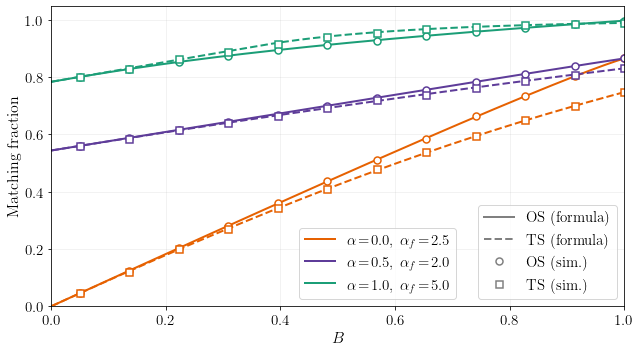

In [119]:
case_colors = ["#E66101", "#5E3C99", "#1B9E77"]

fs = 16
lw = 2
ms = 7

# ── Compute & plot ────
fig, ax = plt.subplots(figsize=(9, 5))

for (alpha, alpha_f), color in zip(cases, case_colors):
    print(f"\n  Case: alpha={alpha}, alpha_f={alpha_f}")

    # Formula curves
    eta_os_f = compute_eta_OS(alpha, alpha_f, B_formula)
    eta_ts_f = compute_eta_TS(alpha, alpha_f, B_formula)
    ax.plot(B_formula, eta_os_f, color=color, linewidth=lw, linestyle='-')
    ax.plot(B_formula, eta_ts_f, color=color, linewidth=lw, linestyle='--')

    # Simulation points
    os_m, ts_m = [], []
    for Bval in B_sim:
        m_os, _ = simulate_matching_rate(alpha, alpha_f, Bval, 'OS',
                                         n=n, n_trials=n_trials)
        m_ts, _ = simulate_matching_rate(alpha, alpha_f, Bval, 'TS',
                                         n=n, n_trials=n_trials)
        os_m.append(m_os)
        ts_m.append(m_ts)
        print(f"    B={Bval:.2f}: OS={m_os:.4f}, TS={m_ts:.4f}")

    ax.plot(B_sim, os_m, color=color, linestyle='none',
            marker='o', markersize=ms, markerfacecolor='white',
            markeredgewidth=1.5, markeredgecolor=color)
    ax.plot(B_sim, ts_m, color=color, linestyle='none',
            marker='s', markersize=ms, markerfacecolor='white',
            markeredgewidth=1.5, markeredgecolor=color)

# ── Legend ────
style_handles = [
    Line2D([0], [0], color='grey', linewidth=lw, linestyle='-',
           label='OS (formula)'),
    Line2D([0], [0], color='grey', linewidth=lw, linestyle='--',
           label='TS (formula)'),
    Line2D([0], [0], color='grey', linestyle='none', marker='o',
           markersize=ms, markerfacecolor='white', markeredgewidth=1.5,
           markeredgecolor='grey', label='OS (sim.)'),
    Line2D([0], [0], color='grey', linestyle='none', marker='s',
           markersize=ms, markerfacecolor='white', markeredgewidth=1.5,
           markeredgecolor='grey', label='TS (sim.)'),
]

case_handles = [
    Line2D([0], [0], color=c, linewidth=lw,
           label=rf"$\alpha\!=\!{a},\;\alpha_f\!=\!{af}$")
    for (a, af), c in zip(cases, case_colors)
]

leg1 = ax.legend(handles=style_handles, frameon=True, fontsize=fs - 1,
                 loc='lower right')
ax.add_artist(leg1)
ax.legend(handles=case_handles, frameon=True, fontsize=fs - 1,
          loc='lower right', bbox_to_anchor=(0.72, 0.0))

ax.set_xlabel(r"$B$", fontsize=fs)
ax.set_ylabel(r"Matching fraction", fontsize=fs)
ax.tick_params(labelsize=fs - 1)
ax.set_xlim(0, 1)
ax.set_ylim(0, None)
ax.grid(alpha=0.2)
fig.tight_layout()
#plt.show()
plt.savefig("fig-comparison.pdf", bbox_inches="tight")

## Plotting $\Delta$ against $\alpha_f$ when $B=1$

### $\alpha < 1$

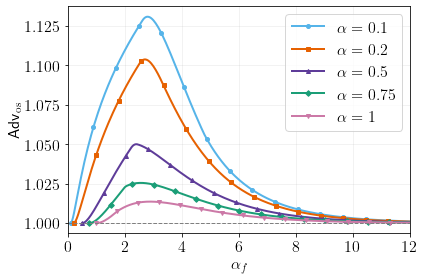

In [197]:
# ── Parameters ────
B = 1.0
alphas = [0.1, 0.2, 0.5, 0.75, 1]
af_npts = 300
af_max = 12.0

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#CC79A7"]
markers = ["o", "s", "^", "D", "v"]

# ── Computation ────
results = {}
for alpha in alphas:
    af_arr = np.linspace(alpha, af_max, af_npts)
    eta_os = compute_eta_OS(alpha, af_arr, B)
    eta_ts = compute_eta_TS(alpha, af_arr, B)
    results[alpha] = (af_arr, eta_os / eta_ts)

# ── Plotting ─────
fs = 16
lw = 2
ms = 4

fig, ax = plt.subplots(figsize=(6, 4))

for alpha, color, marker in zip(alphas, colors, markers):
    af_arr, delta = results[alpha]
    ax.plot(af_arr, delta, color=color, linewidth=lw,
            marker = marker, markevery=20, markersize = ms,
            label=rf"$\alpha = {alpha}$")

ax.axhline(1, color="grey", linewidth= 1 , linestyle="--")
ax.set_xlabel(r"$\alpha_f$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, af_max)
ax.legend(frameon=True, fontsize=fs)
ax.tick_params(labelsize=fs)
ax.grid(alpha = 0.2)
fig.tight_layout()

#plt.show()
plt.savefig("fig-Adv-vs-alphaF-1.pdf", bbox_inches="tight")

### $\alpha > 1$

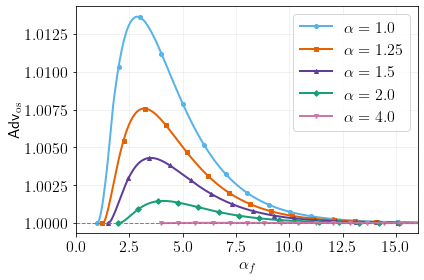

In [196]:
# ── Parameters ─────
B = 1.0
alphas = [1.0, 1.25, 1.5, 2.0, 4.0]
af_npts = 300
af_max = 12.0

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#CC79A7"]
markers = ["o", "s", "^", "D", "v"]

# ── Computation ─────
results = {}
for alpha in alphas:
    af_arr = np.linspace(alpha, af_max, af_npts)
    eta_os = compute_eta_OS(alpha, af_arr, B)
    eta_ts = compute_eta_TS(alpha, af_arr, B)
    results[alpha] = (af_arr, eta_os / eta_ts)

# ── Plotting ─────
fs = 16
lw = 2
ms = 4

fig, ax = plt.subplots(figsize=(6, 4))

for alpha, color, marker in zip(alphas, colors, markers):
    af_arr, delta = results[alpha]
    ax.plot(af_arr, delta, color=color, linewidth=lw,
            marker = marker, markevery=20, markersize = ms,
            label=rf"$\alpha = {alpha}$")

ax.axhline(1, color="grey", linewidth= 1 , linestyle="--")
ax.set_xlabel(r"$\alpha_f$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, af_max)
ax.legend(frameon=True, fontsize=fs)
ax.tick_params(labelsize=fs)
ax.grid(alpha = 0.2)
fig.tight_layout()
#plt.show()
plt.savefig("fig-Adv-vs-alphaF-2.pdf", bbox_inches="tight")

## Plotting $\Delta$ against $\alpha_f$ when $B = 0.6$

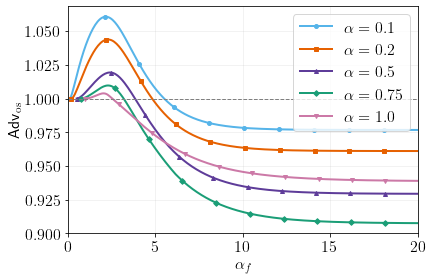

In [201]:
# ── Parameters ────
B = 0.6
alphas = [0.1, 0.2, 0.5, 0.75, 1.0]
af_npts = 300
af_max = 20.0

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#CC79A7"]
markers = ["o", "s", "^", "D", "v"]

# ── Computation ─────
results = {}
for alpha in alphas:
    af_arr = np.linspace(alpha, af_max, af_npts)
    eta_os = compute_eta_OS(alpha, af_arr, B)
    eta_ts = compute_eta_TS(alpha, af_arr, B)
    results[alpha] = (af_arr, eta_os / eta_ts)

# ── Plotting ─────
fs = 16
lw = 2
ms = 4

fig, ax = plt.subplots(figsize=(6, 4))

for alpha, color, marker in zip(alphas, colors, markers):
    af_arr, delta = results[alpha]
    ax.plot(af_arr, delta, color=color, linewidth=lw,
            marker = marker, markevery=30, markersize = ms,
            label=rf"$\alpha = {alpha}$")

ax.axhline(1, color="grey", linewidth= 1 , linestyle="--")
ax.set_xlabel(r"$\alpha_f$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, af_max)
ax.legend(frameon=True, fontsize=fs)
ax.tick_params(labelsize=fs)
ax.grid(alpha = 0.2)
fig.tight_layout()

#plt.show()
plt.savefig("fig-Adv-vs-alphaF-3.pdf", bbox_inches="tight")

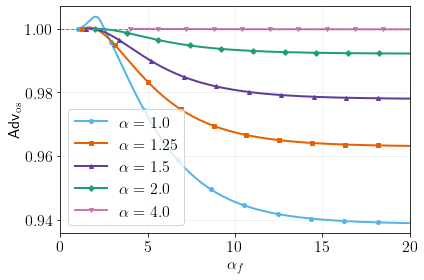

In [199]:
# ── Parameters ─────
B = 0.6
alphas = [1.0, 1.25, 1.5, 2.0, 4.0]
af_npts = 300
af_max = 20.0

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#CC79A7"]
markers = ["o", "s", "^", "D", "v"]

# ── Computation ──────
results = {}
for alpha in alphas:
    af_arr = np.linspace(alpha, af_max, af_npts)
    eta_os = compute_eta_OS(alpha, af_arr, B)
    eta_ts = compute_eta_TS(alpha, af_arr, B)
    results[alpha] = (af_arr, eta_os / eta_ts)

# ── Plotting ─────
fs = 16
lw = 2
ms = 4

fig, ax = plt.subplots(figsize=(6, 4))

for alpha, color, marker in zip(alphas, colors, markers):
    af_arr, delta = results[alpha]
    ax.plot(af_arr, delta, color=color, linewidth=lw,
            marker = marker, markevery=30, markersize = ms,
            label=rf"$\alpha = {alpha}$")

ax.axhline(1, color="grey", linewidth= 1 , linestyle="--")
ax.set_xlabel(r"$\alpha_f$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, af_max)
ax.legend(frameon=True, fontsize=fs)
ax.tick_params(labelsize=fs)
ax.grid(alpha = 0.2)
fig.tight_layout()
#plt.show()
plt.savefig("fig-Adv-vs-alphaF-4.pdf", bbox_inches="tight")

## Plot against $B$

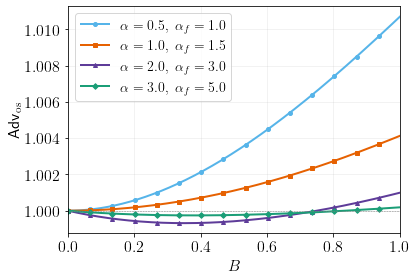

In [65]:
# ── Parameters ─────
cases = [
    (0.5, 1.0),
    (1.0, 1.5),
    (2.0, 3.0),
    (3.0, 5.0),
]
B_arr = np.linspace(0.0, 1.0, 300)

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#009E73", "#D55E00"]
markers = ["o", "s", "^", "D"]

# ── Computation ────
fs = 16
lw = 2
ms = 4

fig, ax = plt.subplots(figsize=(6, 4))

for (alpha, alpha_f), color, marker in zip(cases, colors, markers):
    eta_os = compute_eta_OS(alpha, alpha_f, B_arr)
    eta_ts = compute_eta_TS(alpha, alpha_f, B_arr)
    delta = eta_os / eta_ts
    ax.plot(B_arr, delta, color=color, linewidth=lw,
            marker = marker, markevery=20, markersize = ms,
            label=rf"$\alpha = {alpha},\; \alpha_f = {alpha_f}$")

ax.axhline(1, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(r"$B$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, 1)
ax.legend(frameon=True, fontsize=fs-2)
ax.tick_params(labelsize=fs)
ax.grid(alpha = 0.2)

fig.tight_layout()
#plt.show()
plt.savefig("fig-Adv-vs-B-1.pdf", bbox_inches="tight")

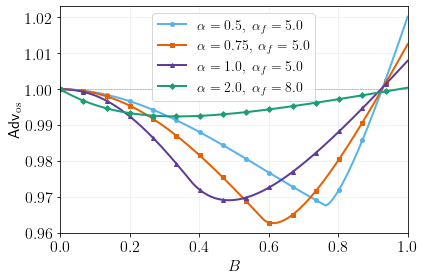

In [66]:
# ── Parameters ───
cases = [
    (0.5, 5.0),
    (0.75, 5.0),
    (1.0, 5.0),
    (2.0, 8.0),
]

B_arr = np.linspace(0.0, 1.0, 300)

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#009E73", "#D55E00"]
markers = ["o", "s", "^", "D"]

# ── Computation ───
fs = 16
lw = 2
ms = 4


fig, ax = plt.subplots(figsize=(6, 4))

for (alpha, alpha_f), color, marker in zip(cases, colors, markers):
    eta_os = compute_eta_OS(alpha, alpha_f, B_arr)
    eta_ts = compute_eta_TS(alpha, alpha_f, B_arr)
    delta = eta_os / eta_ts
    ax.plot(B_arr, delta, color=color, linewidth=lw,
            marker = marker, markevery=20, markersize = ms,
            label=rf"$\alpha = {alpha},\; \alpha_f = {alpha_f}$")

ax.axhline(1, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(r"$B$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, 1)
ax.legend(frameon=True, fontsize=fs-2)
ax.tick_params(labelsize=fs)
ax.grid(alpha = 0.2)

fig.tight_layout()
#plt.show()
plt.savefig("fig-Adv-vs-B-2.pdf", bbox_inches="tight")

## Plotting $\mathsf{Adv}_{\mathrm{OS}}$ when $\alpha=0$

### Against $\alpha_f$

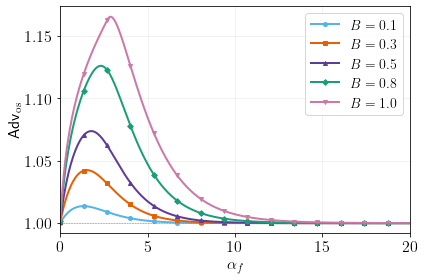

In [214]:
B_cases = [0.1, 0.3, 0.5, 0.8,  1.0]
af_arr = np.linspace(0.01, 20.0, 300)

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#CC79A7"]
markers = ["o", "s", "^", "D", "v"]

fs = 16
lw = 2
ms = 4

fig, ax = plt.subplots(figsize=(6, 4))
for B, color, marker in zip(B_cases, colors, markers):
    eta_os = compute_eta_OS(0.0, af_arr, B)
    eta_ts = compute_eta_TS(0.0, af_arr, B)
    adv = np.where(eta_ts > 1e-12, eta_os / eta_ts, 1.0)
    ax.plot(af_arr, adv, color=color, linewidth=lw,
            marker=marker, markevery=20, markersize=ms,
            label=rf"$B = {B}$")

ax.axhline(1, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(r"$\alpha_f$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, 20)
ax.legend(frameon=True, fontsize=fs - 2)
ax.tick_params(labelsize=fs)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.savefig("fig-alpha0-vs-alphaf.pdf", bbox_inches="tight")

### Against $B$

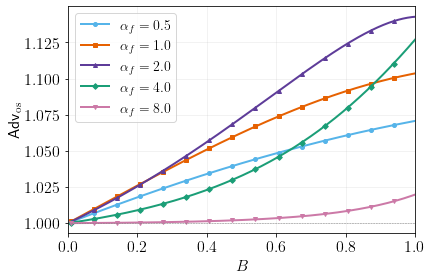

In [213]:
af_cases = [0.5, 1.0, 2.0, 4.0, 8.0]
B_arr = np.linspace(0.01, 1.0, 300)

colors = ["#56B4E9", "#E66101", "#5E3C99", "#1B9E77", "#CC79A7"]
markers = ["o", "s", "^", "D", "v"]

fs = 16
lw = 2
ms = 4

fig, ax = plt.subplots(figsize=(6, 4))
for af, color, marker in zip(af_cases, colors, markers):
    eta_os = compute_eta_OS(0.0, af, B_arr)
    eta_ts = compute_eta_TS(0.0, af, B_arr)
    adv = np.where(eta_ts > 1e-12, eta_os / eta_ts, 1.0)
    ax.plot(B_arr, adv, color=color, linewidth=lw,
            marker=marker, markevery=20, markersize=ms,
            label=rf"$\alpha_f = {af}$")

ax.axhline(1, color="grey", linewidth=0.5, linestyle="--")
ax.set_xlabel(r"$B$", fontsize=fs)
ax.set_ylabel(r"$\mathsf{Adv}_{ \small \mathrm{os}}$", fontsize=fs)
ax.set_xlim(0, 1)
ax.legend(frameon=True, fontsize=fs - 2)
ax.tick_params(labelsize=fs)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.savefig("fig-alpha0-vs-B.pdf", bbox_inches="tight")

## HEATMAPS

In [202]:
B_range = np.array([0.1, 0.2, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

alpha_max = 6.0
diff_max = 6.0
n_alpha = 100
n_diff = 100
fs = 25

c_os = "#E66101"
c_ts = "#5E3C99"
binary_cmap = mcolors.ListedColormap([c_ts, c_os])
binary_norm = mcolors.BoundaryNorm([0, 1, 2], binary_cmap.N)

alpha_arr = np.linspace(0.01, alpha_max, n_alpha)
diff_arr = np.linspace(0.02, diff_max, n_diff)
ALPHA, DIFF = np.meshgrid(alpha_arr, diff_arr, indexing='ij')
AF = ALPHA + DIFF

for B in tqdm(B_range, desc="Heatmaps"):
    eta_os = compute_eta_OS(ALPHA, AF, B)
    eta_ts = compute_eta_TS(ALPHA, AF, B)
    gap = eta_os - eta_ts

    tol = 1e-10
    binary_data = np.ones_like(gap)
    binary_data[gap > tol] = 1.0
    binary_data[gap < -tol] = 0.0
    binary_data[np.abs(gap) <= tol] = 1.0

    reliable = (eta_ts < 1 - 1e-8) | (eta_os < 1 - 1e-8)
    gap_masked = np.where(reliable, gap, np.nan)

    fig1, ax1 = plt.subplots(figsize=(7, 5))
    ax1.pcolormesh(diff_arr, alpha_arr, binary_data,
                   cmap=binary_cmap, norm=binary_norm,
                   shading='nearest', rasterized=True, alpha=0.95)
    ax1.contour(diff_arr, alpha_arr, gap_masked, levels=[0],
                colors='black', linewidths=3.5)
    ax1.contour(diff_arr, alpha_arr, gap_masked, levels=[0],
                colors='white', linewidths=3.5)
    ax1.contourf(diff_arr, alpha_arr, binary_data, levels=[-0.5, 0.5],
                 colors='none', hatches=['///'], alpha=0)
    ax1.set_xlabel(r"$\alpha_f - \alpha$", fontsize=fs)
    ax1.set_ylabel(r"$\alpha$", fontsize=fs)
    ax1.tick_params(labelsize=fs)
    
    legend_elements = [
        Patch(facecolor=c_os, alpha=0.8,
              label=r"$\mathsf{Adv}_{\mathrm{os}} \geq 1$"),
        Patch(facecolor=c_ts, alpha=0.8, hatch='///', edgecolor='black',
              label=r"$\mathsf{Adv}_{\mathrm{os}} < 1$"),
    ]
    ax1.legend(handles=legend_elements, frameon=True, fontsize=fs,
               loc='upper right')
    fig1.tight_layout()
    plt.savefig(f"fig-Heatmap-{int(round(100 * B))}.pdf", bbox_inches="tight")
    plt.close(fig1)

Heatmaps:  89%|███████████████████████████████    | 8/9 [06:24<00:48, 48.07s/it]/var/folders/tw/7bcq2jks07v885fy40ytt8l80000gn/T/ipykernel_58303/4047734455.py:37: UserWarning: No contour levels were found within the data range.
  ax1.contour(diff_arr, alpha_arr, gap_masked, levels=[0],
/var/folders/tw/7bcq2jks07v885fy40ytt8l80000gn/T/ipykernel_58303/4047734455.py:39: UserWarning: No contour levels were found within the data range.
  ax1.contour(diff_arr, alpha_arr, gap_masked, levels=[0],
Heatmaps: 100%|███████████████████████████████████| 9/9 [07:12<00:00, 48.11s/it]
